In [5]:
import sys
import os
import numpy as np
# Adiciona a pasta src ao path para importar os módulos
sys.path.append(os.path.abspath(os.path.join('..')))

import torch
import torch.nn as nn
import torch.optim as optim
from src.dataset import get_svhn_loaders
from src.model import SVHNNet
from src.train_utils import capture_optimizer_internals
from src.visualization import plot_gradients_distribution, plot_gradients_distribution_with_sma

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando device: {device}")

Usando device: cpu


## Loop de Treino Customizado para Captura

In [2]:
# Carrega dados
train_loader, test_loader = get_svhn_loaders(batch_size=64)

# Inicializa Modelo e Otimizador (Adam é obrigatório para ver a adaptação)
model = SVHNNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Listas para guardar snapshots dos gradientes
grads_history = []

# Treina por apenas 1 época para demonstração (ou mais se quiser)
model.train()
print("Iniciando treino para captura de gradientes...")

for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, target)
    loss.backward()
    
    # --- CAPTURA ANTES DO STEP ---
    # Capturamos a cada 100 batches para não lotar a memória
    if batch_idx % 100 == 0:
        raw, ewma, adapted = capture_optimizer_internals(model, optimizer, layer_name='conv1')
        if raw is not None:
            grads_history.append((batch_idx, raw, ewma, adapted))
    
    optimizer.step()

print("Captura finalizada.")

100%|██████████| 182M/182M [00:39<00:00, 4.64MB/s] 


100%|██████████| 64.3M/64.3M [00:12<00:00, 5.00MB/s]


Iniciando treino para captura de gradientes...
Captura finalizada.


In [9]:
train_loader, test_loader = get_svhn_loaders(batch_size=64)
model = SVHNNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# --- Configuração da Captura SMA ---
SMA_WINDOW = 10  # Tamanho da janela da média simples
raw_grads_buffer = [] # Lista para guardar os últimos 10 gradientes crus

captured_data = None

model.train()
print("Iniciando loop curto para capturar histórico para SMA...")

for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, target)
    loss.backward()
    
    # --- CAPTURA DOS GRADIENTES CRUS ---
    # Pega o gradiente da camada conv1
    current_raw_grad = model.conv1.weight.grad.data.cpu().numpy().flatten()
    
    # Adiciona ao buffer
    raw_grads_buffer.append(current_raw_grad)
    
    # Mantém o buffer apenas com o tamanho da janela
    if len(raw_grads_buffer) > SMA_WINDOW:
        raw_grads_buffer.pop(0)
        
    # --- PONTO DE DISPARO DA VISUALIZAÇÃO ---
    # Vamos capturar no batch 20, quando já temos histórico suficiente
    if batch_idx == 100:
        print("Histórico preenchido. Calculando SMA e capturando estados do Adam...")
        
        # 1. O Gradiente Cru atual
        raw_final = current_raw_grad
        
        # 2. Calcula a SMA (Média dos buffers acumulados)
        # np.stack transforma a lista de arrays em uma matriz 2D, depois tiramos a média
        sma_final = np.mean(np.stack(raw_grads_buffer), axis=0)
        
        # 3. Captura os estados reais do Adam (EWMA e Adaptado)
        state = optimizer.state[model.conv1.weight]
        ewma_final = state['exp_avg'].cpu().numpy().flatten()
        
        exp_avg_sq = state['exp_avg_sq'].cpu().numpy().flatten()
        denom = np.sqrt(exp_avg_sq) + optimizer.param_groups[0]['eps']
        adapted_final = ewma_final / denom
        
        # Salva tudo e para o treino
        captured_data = (raw_final, sma_final, ewma_final, adapted_final)
        break
    
    optimizer.step()

print("Captura finalizada.")

Using downloaded and verified file: ./data/train_32x32.mat
Using downloaded and verified file: ./data/test_32x32.mat
Iniciando loop curto para capturar histórico para SMA...
Histórico preenchido. Calculando SMA e capturando estados do Adam...
Captura finalizada.


## Visualização (Gera os gráficos do Tópico 3)

Visualizando distribuição do Batch 1100


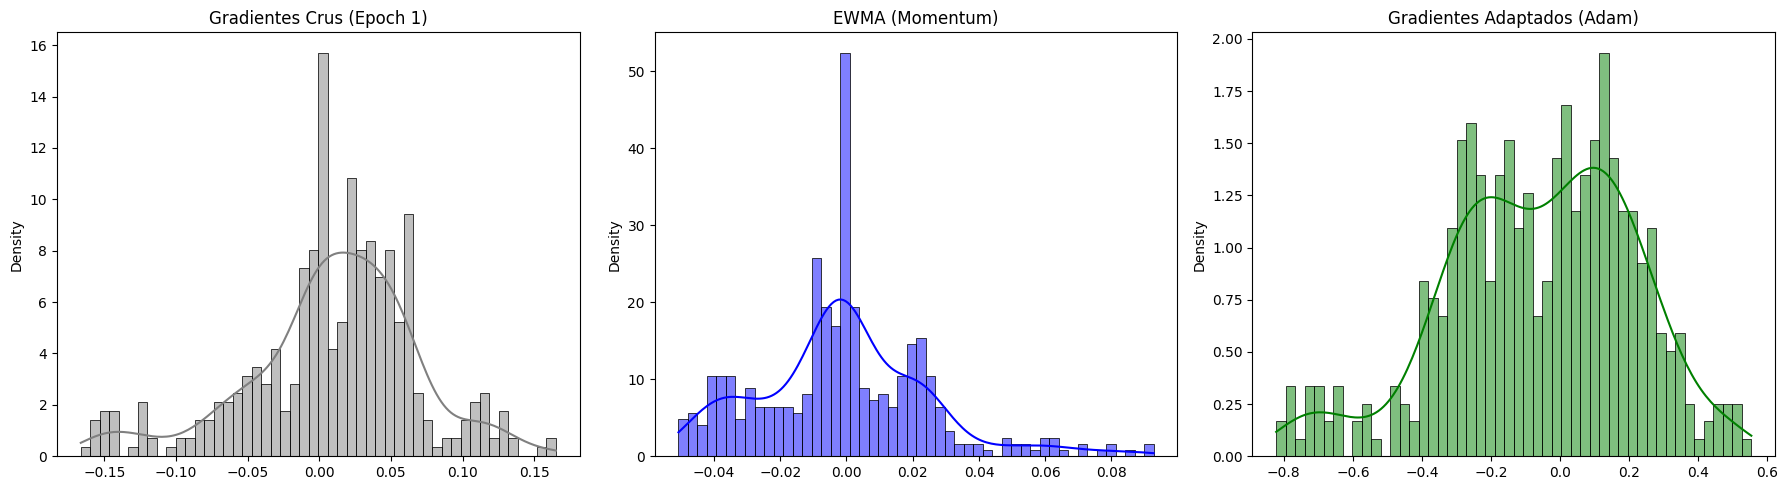

In [8]:
# Pega o último snapshot capturado
idx, raw, ewma, adapted = grads_history[-1]

print(f"Visualizando distribuição do Batch {idx}")
plot_gradients_distribution(raw, ewma, adapted, epoch_idx=1)

Gerando gráfico comparativo...


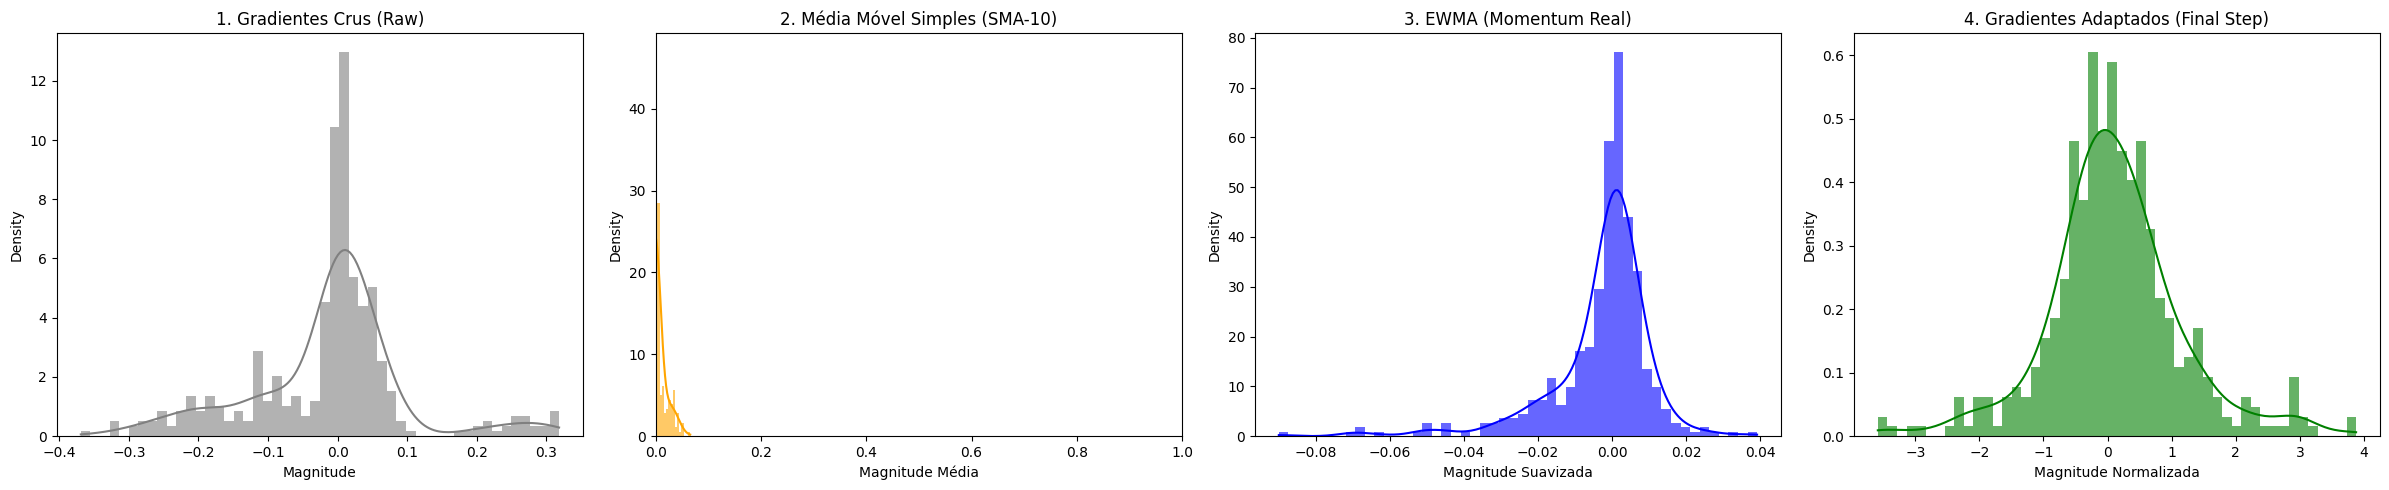

In [10]:
if captured_data:
    raw, sma, ewma, adapted = captured_data
    print("Gerando gráfico comparativo...")
    plot_gradients_distribution_with_sma(raw, sma, ewma, adapted)
else:
    print("Erro: Dados não foram capturados.")